# NB11 — Vigor ODE: Leaky-integrator dynamics across encounter and no-encounter trials

**Core question**: If press rate is an instrumental urgency signal (pressing faster = higher escape probability),
then the within-trial dynamics should reflect a leaky-integrator driven by threat:

```
dv/dt = α × (v_target(t) − v(t))
```

where `v_target` is low before encounter (background threat) and high after (reactive threat).
This gives an analytical solution for the post-encounter rise:

```
v(t_rel) = v_max − (v_max − v_pre) × exp(−α × t_rel)    [t_rel ≥ 0]
```

**Three contrasting analyses**:
- **A. Tonic**: No-encounter trials → how does mean pressing scale with threat probability?
- **B. Encounter dynamics**: Encounter-aligned epochs → fit leaky-integrator, extract α and v_max
- **C. Correlation**: Do ODE parameters (α, v_max, tonic level) relate to model parameters (z, κ, β)?

**Encounter vs. no-encounter as contrast**:
No-encounter trials provide the pure anticipated-threat baseline. Encounter trials add the reactive component.
The difference isolates the reactive signal.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import curve_fit
from scipy import stats
import warnings
from pathlib import Path

BASE        = Path('/Users/nokada/Desktop/EffortForagingUnderThreat')
VIGOR_PROC  = BASE / 'data/exploratory_350/processed/vigor_processed'
STATS_DIR   = BASE / 'results/stats'
FIG_DIR     = BASE / 'results/figures/vigor_ode'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Analysis constants
PRE_WINDOW  = (-3.0, 0.0)   # seconds before encounter for baseline
POST_WINDOW = (0.0, 10.0)   # seconds after encounter for ODE fit
BIN_SIZE    = 0.05           # 20 Hz
MIN_ENC_TRIALS = 15          # minimum encounter trials for per-subject fit
N_PERM      = 5000

THREAT_COLORS = {0.1: '#2196F3', 0.5: '#FF9800', 0.9: '#F44336'}

print('Libraries loaded.')

Libraries loaded.


## 1. Load data

In [2]:
# ── Time series ──────────────────────────────────────────────────────────────
ts = pd.read_parquet(VIGOR_PROC / 'smoothed_vigor_ts.parquet')

# Harmonise column names to match rest of pipeline
_rename = {
    'isAttackTrial':   'encounter',
    'encounterTime':   'encounter_time',
    'trialEscapeTime': 'escape_time',
    'trialCaptureTime':'capture_time',
    'trialEndTime':    'trial_end_time',
    'vigor_norm':      'v_t',
}
ts = ts.rename(columns={k: v for k, v in _rename.items() if k in ts.columns})

print(f'Time series: {ts.shape[0]:,} rows, {ts["subj"].nunique()} subjects, {ts["trial"].nunique()} unique trial indices')
print(f'Encounter trials: {ts.groupby(["subj","trial"])["encounter"].first().sum():.0f} / {ts["subj"].nunique() * ts["trial"].nunique()}')

# ── Model parameters ─────────────────────────────────────────────────────────
# params CSVs use 'subject' column (not 'subj')
z_df    = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_z_params.csv')[['subject','mean']].rename(columns={'subject':'subj','mean':'z'})
k_df    = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_k_params.csv')[['subject','mean']].rename(columns={'subject':'subj','mean':'kappa'})
beta_df = pd.read_csv(STATS_DIR / 'FET_Exp_Bias_beta_params.csv')[['subject','mean']].rename(columns={'subject':'subj','mean':'beta'})
params  = z_df.merge(k_df, on='subj').merge(beta_df, on='subj')
print(f'Parameters: {len(params)} subjects')

# Keep only subjects present in both
common_subj = set(ts['subj'].unique()) & set(params['subj'].unique())
ts     = ts[ts['subj'].isin(common_subj)].copy()
params = params[params['subj'].isin(common_subj)].reset_index(drop=True)
print(f'Common subjects: {len(common_subj)}')

Time series: 3,988,277 rows, 293 subjects, 81 unique trial indices


Encounter trials: 11700 / 23733
Parameters: 293 subjects
Common subjects: 293


## 2. Analysis A — Tonic pressing on no-encounter trials (aligned to scheduled encounter time)

No-encounter trials (`encounter == 0`) have `encounter_time` set to the *scheduled* predator appearance time.
Aligning to this gives the counterfactual baseline: what pressing looked like at the same trial moment,
without an actual attack. This is the correct contrast for the encounter-aligned analysis in B and C.

Threat probability modulates background urgency — pressing should be higher in high-threat patches
even before (and without) an actual encounter.

Tonic pre-encounter pressing (no-encounter trials):
count    293.000000
mean       0.477959
std        0.332250
min        0.000000
25%        0.186323
50%        0.445145
75%        0.743663
max        1.270999
Name: v_tonic_mean, dtype: float64


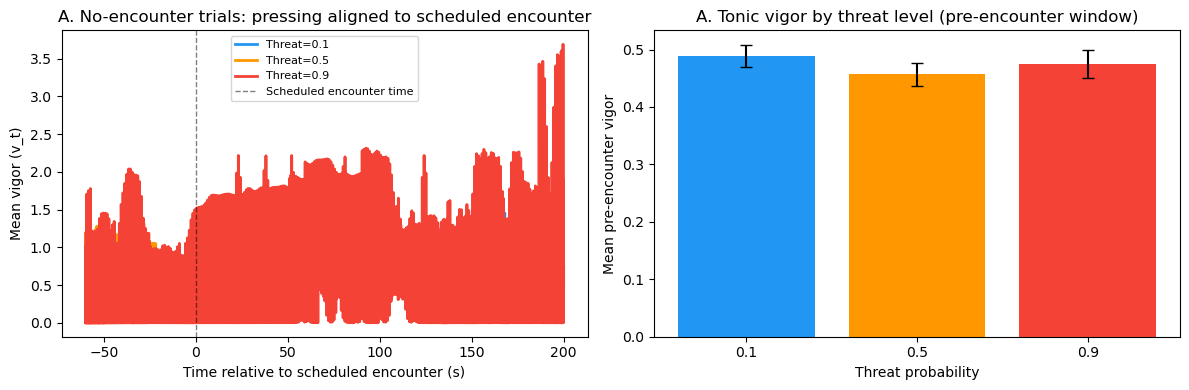

  threat 0.1 vs 0.5: t=4.58, p=0.000, d=-0.27
  threat 0.1 vs 0.9: t=0.90, p=0.370, d=-0.05
  threat 0.5 vs 0.9: t=-1.26, p=0.209, d=0.07


In [3]:
no_enc = ts[ts['encounter'] == 0].copy()

# Align to scheduled encounter time (same reference frame as encounter trials)
no_enc['t_rel'] = no_enc['t'] - no_enc['encounter_time']
no_enc = no_enc[(no_enc['t_rel'] >= PRE_WINDOW[0]) & (no_enc['t_rel'] <= POST_WINDOW[1])].copy()
no_enc['t_rel_bin'] = (no_enc['t_rel'] / BIN_SIZE).round(2)

# ── Subject × threat mean tonic vigor (overall, for correlation with params) ─
# Use pre-encounter window only (t_rel in [-1, 0]) for clean tonic estimate
tonic_mean = (
    no_enc[no_enc['t_rel_bin'].between(-1.0, 0.0)]
    .groupby('subj')['v_t']
    .mean()
    .reset_index()
    .rename(columns={'v_t': 'v_tonic_mean'})
)

# Per-subject tonic vigor at each threat level
tonic_subj = (
    no_enc[no_enc['t_rel_bin'].between(-1.0, 0.0)]
    .groupby(['subj', 'threat'])['v_t']
    .mean()
    .reset_index()
    .rename(columns={'v_t': 'v_tonic'})
)

# Per-subject threat sensitivity: slope of tonic vigor ~ threat_prob
def threat_slope(df):
    means = df.groupby('threat')['v_t'].mean()
    if len(means) < 2:
        return np.nan
    x = np.array(means.index.astype(float))
    y = np.array(means.values)
    return np.polyfit(x, y, 1)[0]

tonic_slope = (
    no_enc[no_enc['t_rel_bin'].between(-1.0, 0.0)]
    .groupby('subj')
    .apply(threat_slope)
    .reset_index()
    .rename(columns={0: 'tonic_threat_slope'})
)

print('Tonic pre-encounter pressing (no-encounter trials):')
print(tonic_mean['v_tonic_mean'].describe())

# ── Group mean traces aligned to encounter_time, by threat level ─────────────
tonic_trace = (
    no_enc.groupby(['threat', 't_rel_bin'])['v_t']
    .mean()
    .reset_index()
)

# ── Plot A ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
for threat_val, grp in tonic_trace.groupby('threat'):
    ax.plot(grp['t_rel_bin'], grp['v_t'], color=THREAT_COLORS[threat_val],
            label=f'Threat={threat_val}', linewidth=2)
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.5, label='Scheduled encounter time')
ax.set_xlabel('Time relative to scheduled encounter (s)')
ax.set_ylabel('Mean vigor (v_t)')
ax.set_title('A. No-encounter trials: pressing aligned to scheduled encounter')
ax.legend(fontsize=8)

ax = axes[1]
threat_means = tonic_subj.groupby('threat')['v_tonic'].agg(['mean','sem']).reset_index()
ax.bar([str(t) for t in threat_means['threat']], threat_means['mean'],
       yerr=threat_means['sem'], capsize=4,
       color=[THREAT_COLORS[t] for t in threat_means['threat']])
ax.set_xlabel('Threat probability')
ax.set_ylabel('Mean pre-encounter vigor')
ax.set_title('A. Tonic vigor by threat level (pre-encounter window)')

plt.tight_layout()
plt.savefig(FIG_DIR / 'A_tonic_by_threat.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Stats: does tonic vigor scale with threat? ────────────────────────────────
for threat_pair in [(0.1, 0.5), (0.1, 0.9), (0.5, 0.9)]:
    a = tonic_subj[tonic_subj['threat'] == threat_pair[0]]['v_tonic'].values
    b = tonic_subj[tonic_subj['threat'] == threat_pair[1]]['v_tonic'].values
    if len(a) != len(b):
        print(f'  threat {threat_pair[0]} vs {threat_pair[1]}: unequal n ({len(a)} vs {len(b)}), skipping')
        continue
    t_stat, p = stats.ttest_rel(a, b)
    d = np.mean(b - a) / np.std(b - a)
    print(f'  threat {threat_pair[0]} vs {threat_pair[1]}: t={t_stat:.2f}, p={p:.3f}, d={d:.2f}')

## 3. Analysis B — Encounter-aligned dynamics

For encounter trials, align the vigor time series to the encounter onset (`t_rel = t - encounter_time`).
Average per subject to get a clean epoch, then fit the leaky-integrator solution:

```
v(t_rel) = v_max − (v_max − v_pre) × exp(−α × t_rel)    [t_rel ≥ 0]
```

Parameters extracted per subject: `v_pre` (pre-encounter level), `v_max` (asymptote), `α` (rise rate in 1/s).

In [4]:
enc = ts[ts['encounter'] == 1].copy()

# Encounter-relative time
enc['t_rel'] = enc['t'] - enc['encounter_time']

# Keep window around encounter
enc = enc[(enc['t_rel'] >= PRE_WINDOW[0]) & (enc['t_rel'] <= POST_WINDOW[1])].copy()

# Bin t_rel
enc['t_rel_bin'] = (enc['t_rel'] / BIN_SIZE).round(2)

print(f'Encounter rows in window: {len(enc):,}')
print(f'Encounter trials per subject range: {enc.groupby(["subj","trial"]).ngroups / enc["subj"].nunique():.1f} (mean)')

# ── Per-subject encounter-aligned average ─────────────────────────────────────
subj_enc_trace = (
    enc.groupby(['subj', 't_rel_bin'])['v_t']
    .mean()
    .reset_index()
    .rename(columns={'v_t': 'v_mean'})
)

# Group-level average for visualisation
group_enc_trace = (
    subj_enc_trace.groupby('t_rel_bin')['v_mean']
    .agg(['mean', 'sem'])
    .reset_index()
)

# Also by threat level for group trace
enc_by_threat = (
    enc.groupby(['threat', 't_rel_bin'])['v_t']
    .mean()
    .reset_index()
    .rename(columns={'v_t': 'v_mean'})
)

print(f'Subjects with ≥{MIN_ENC_TRIALS} encounter trials: {(enc.groupby("subj")["trial"].nunique() >= MIN_ENC_TRIALS).sum()}')

Encounter rows in window: 1,647,938


Encounter trials per subject range: 39.9 (mean)


Subjects with ≥15 encounter trials: 293


In [5]:
# ── Leaky-integrator curve fit ────────────────────────────────────────────────

def exp_rise(t_rel, v_max, alpha):
    """Post-encounter leaky-integrator solution (t_rel >= 0 only).
    v_pre is fixed from the pre-encounter window average.
    v(t) = v_max - (v_max - v_pre) * exp(-alpha * t)
    """
    return v_max - (v_max - exp_rise._v_pre) * np.exp(-alpha * t_rel)


def fit_subject_ode(subj_df, min_post_bins=20):
    """Fit leaky integrator to one subject's encounter-aligned trace."""
    pre  = subj_df[subj_df['t_rel_bin'] < 0]
    post = subj_df[subj_df['t_rel_bin'] >= 0].sort_values('t_rel_bin')

    if len(post) < min_post_bins:
        return dict(v_pre=np.nan, v_max=np.nan, alpha=np.nan)

    # Pre-encounter baseline: last 0.5s before encounter
    v_pre = pre[pre['t_rel_bin'] >= -0.5]['v_mean'].mean() if len(pre) > 0 else post['v_mean'].iloc[0]
    if np.isnan(v_pre):
        v_pre = post['v_mean'].iloc[0]

    exp_rise._v_pre = v_pre  # inject into closure

    t_post = post['t_rel_bin'].values.astype(float)
    v_post = post['v_mean'].values

    # Initial guesses: v_max = 90th pct of post-encounter, alpha = 1.0 /s
    v_max_init = np.percentile(v_post, 90)
    p0 = [max(v_max_init, v_pre + 0.01), 0.5]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            popt, _ = curve_fit(
                exp_rise, t_post, v_post,
                p0=p0,
                bounds=([v_pre, 0.01], [np.inf, 20.0]),
                maxfev=2000
            )
        v_max_fit, alpha_fit = popt
        return dict(v_pre=v_pre, v_max=v_max_fit, alpha=alpha_fit)
    except Exception:
        return dict(v_pre=v_pre, v_max=np.nan, alpha=np.nan)


# Fit per subject
ode_results = []
for subj_id, sdf in subj_enc_trace.groupby('subj'):
    n_enc = enc[enc['subj'] == subj_id]['trial'].nunique()
    fit = fit_subject_ode(sdf)
    fit['subj'] = subj_id
    fit['n_enc_trials'] = n_enc
    ode_results.append(fit)

ode_df = pd.DataFrame(ode_results)
ode_df['v_amplitude'] = ode_df['v_max'] - ode_df['v_pre']  # reactive amplitude

# Keep only subjects with successful fit and enough trials
ode_good = ode_df[
    (ode_df['n_enc_trials'] >= MIN_ENC_TRIALS) &
    ode_df['alpha'].notna() &
    (ode_df['alpha'] > 0) &
    (ode_df['v_amplitude'] > -0.5)  # exclude nonsense fits
].copy()

print(f'Subjects with valid ODE fit: {len(ode_good)} / {len(ode_df)}')
print()
print('ODE parameter distributions:')
print(ode_good[['v_pre','v_max','alpha','v_amplitude']].describe().round(3))

Subjects with valid ODE fit: 293 / 293

ODE parameter distributions:
         v_pre    v_max    alpha  v_amplitude
count  293.000  293.000  293.000      293.000
mean     0.453    0.869    2.462        0.416
std      0.338    0.259    6.304        0.404
min      0.000    0.486    0.010        0.000
25%      0.152    0.771    0.029        0.029
50%      0.405    0.842    0.061        0.414
75%      0.766    0.906    0.158        0.690
max      1.371    3.999   20.000        3.999


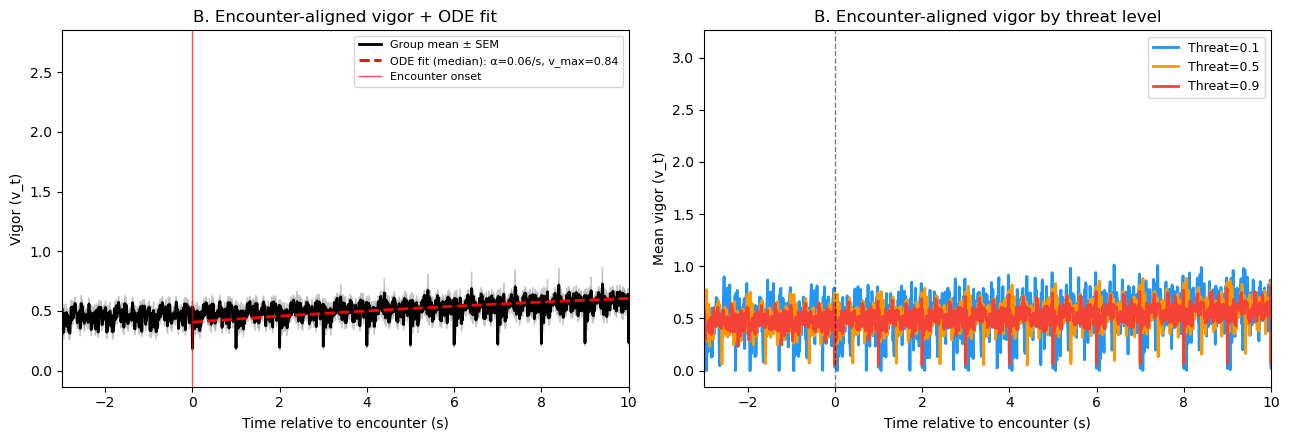

Group ODE parameters (median): v_pre=0.405, v_max=0.842, α=0.061/s
Effective time-to-peak (63% rise): 16.43s


In [6]:
# ── Visualise group encounter-aligned trace + ODE fit ─────────────────────────

# Compute group-level ODE fit from median parameters
med_v_pre   = ode_good['v_pre'].median()
med_v_max   = ode_good['v_max'].median()
med_alpha   = ode_good['alpha'].median()

t_fit = np.linspace(0, POST_WINDOW[1], 200)
exp_rise._v_pre = med_v_pre
v_fit = exp_rise(t_fit, med_v_max, med_alpha)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Left: group mean trace + ODE fit
ax = axes[0]
ax.fill_between(
    group_enc_trace['t_rel_bin'],
    group_enc_trace['mean'] - group_enc_trace['sem'],
    group_enc_trace['mean'] + group_enc_trace['sem'],
    alpha=0.2, color='k'
)
ax.plot(group_enc_trace['t_rel_bin'], group_enc_trace['mean'], 'k-', linewidth=2, label='Group mean ± SEM')
ax.plot(t_fit, v_fit, 'r--', linewidth=2,
        label=f'ODE fit (median): α={med_alpha:.2f}/s, v_max={med_v_max:.2f}')
ax.axvline(0, color='r', lw=1, alpha=0.7, label='Encounter onset')
ax.set_xlabel('Time relative to encounter (s)')
ax.set_ylabel('Vigor (v_t)')
ax.set_title('B. Encounter-aligned vigor + ODE fit')
ax.legend(fontsize=8)
ax.set_xlim(PRE_WINDOW[0], POST_WINDOW[1])

# Right: by threat level
ax = axes[1]
for threat_val, grp in enc_by_threat.groupby('threat'):
    ax.plot(grp['t_rel_bin'], grp['v_mean'],
            color=THREAT_COLORS[threat_val], linewidth=2, label=f'Threat={threat_val}')
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('Time relative to encounter (s)')
ax.set_ylabel('Mean vigor (v_t)')
ax.set_title('B. Encounter-aligned vigor by threat level')
ax.legend(fontsize=9)
ax.set_xlim(PRE_WINDOW[0], POST_WINDOW[1])

plt.tight_layout()
plt.savefig(FIG_DIR / 'B_encounter_aligned.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Group ODE parameters (median): v_pre={med_v_pre:.3f}, v_max={med_v_max:.3f}, α={med_alpha:.3f}/s')
print(f'Effective time-to-peak (63% rise): {1/med_alpha:.2f}s')

## 4. Analysis C — Attack vs no-attack contrast (same encounter_time alignment)

Because `encounter_time` is defined for every trial (scheduled predator time), both trial types share
the same `t_rel` reference frame. The contrast is now exact: at every time bin, attack-trial pressing
minus no-attack-trial pressing at the *same* moment relative to when the predator was scheduled.
Pre-encounter bins should be near zero (trials don't differ before the attack); post-encounter bins
show the pure reactive surge caused by the actual attack.

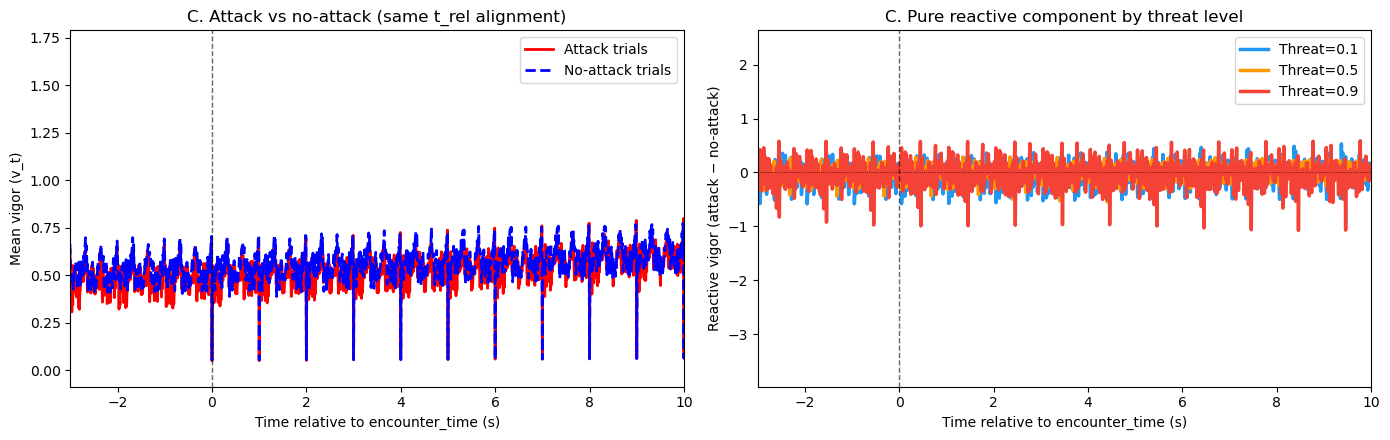

Pre-encounter mean contrast (should be ≈ 0):
  mean=-0.0159, std=0.1169

Peak reactive vigor by threat level (post-encounter):
threat
0.1    2.336767
0.5    2.075948
0.9    1.725591
Name: v_reactive, dtype: float32


In [7]:
# Both trial types are now in the same t_rel frame.
# Compute group-level mean traces for attack and no-attack, then difference.

# No-attack trace (already computed as tonic_trace — but that groups by threat)
# Recompute collapsed across threat for the overall contrast
no_enc_group = (
    no_enc.groupby('t_rel_bin')['v_t']
    .mean()
    .reset_index()
    .rename(columns={'v_t': 'v_no_attack'})
)

enc_group = (
    enc.groupby('t_rel_bin')['v_t']
    .mean()
    .reset_index()
    .rename(columns={'v_t': 'v_attack'})
)

contrast_group = no_enc_group.merge(enc_group, on='t_rel_bin', how='inner')
contrast_group['v_reactive'] = contrast_group['v_attack'] - contrast_group['v_no_attack']

# By threat level
no_enc_by_threat = (
    no_enc.groupby(['threat', 't_rel_bin'])['v_t']
    .mean().reset_index().rename(columns={'v_t': 'v_no_attack'})
)
enc_by_threat_for_contrast = (
    enc.groupby(['threat', 't_rel_bin'])['v_t']
    .mean().reset_index().rename(columns={'v_t': 'v_attack'})
)
contrast_by_threat = no_enc_by_threat.merge(enc_by_threat_for_contrast, on=['threat','t_rel_bin'], how='inner')
contrast_by_threat['v_reactive'] = contrast_by_threat['v_attack'] - contrast_by_threat['v_no_attack']

# ── Plot C ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.plot(contrast_group['t_rel_bin'], contrast_group['v_attack'],   'r-',  lw=2, label='Attack trials')
ax.plot(contrast_group['t_rel_bin'], contrast_group['v_no_attack'],'b--', lw=2, label='No-attack trials')
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.6)
ax.set_xlabel('Time relative to encounter_time (s)')
ax.set_ylabel('Mean vigor (v_t)')
ax.set_title('C. Attack vs no-attack (same t_rel alignment)')
ax.legend()
ax.set_xlim(PRE_WINDOW[0], POST_WINDOW[1])

ax = axes[1]
for threat_val, grp in contrast_by_threat.groupby('threat'):
    ax.plot(grp['t_rel_bin'], grp['v_reactive'],
            color=THREAT_COLORS[threat_val], lw=2.5, label=f'Threat={threat_val}')
ax.axvline(0, color='k', lw=1, ls='--', alpha=0.6)
ax.axhline(0, color='k', lw=0.5, ls=':')
ax.set_xlabel('Time relative to encounter_time (s)')
ax.set_ylabel('Reactive vigor (attack − no-attack)')
ax.set_title('C. Pure reactive component by threat level')
ax.legend()
ax.set_xlim(PRE_WINDOW[0], POST_WINDOW[1])

plt.tight_layout()
plt.savefig(FIG_DIR / 'C_reactive_contrast.png', dpi=150, bbox_inches='tight')
plt.show()

# Peak reactive amplitude per threat level
print('Pre-encounter mean contrast (should be ≈ 0):')
pre = contrast_group[contrast_group['t_rel_bin'] < 0]['v_reactive']
print(f'  mean={pre.mean():.4f}, std={pre.std():.4f}')
print()
print('Peak reactive vigor by threat level (post-encounter):')
peak = (
    contrast_by_threat[contrast_by_threat['t_rel_bin'] >= 0]
    .groupby('threat')['v_reactive']
    .max()
)
print(peak)

## 5. Correlate ODE parameters with model parameters

**Predictions**:
- `v_tonic_mean` (mean pressing on no-encounter trials) ↔ **κ** (effort cost): higher effort aversion → less pressing
- `tonic_threat_slope` (tonic pressing increase per unit threat) ↔ **z** (threat sensitivity): more sensitive → stronger modulation by threat probability
- `α` (post-encounter rise rate) ↔ **z**: faster threat integration → faster pressing ramp-up  
- `v_amplitude` (reactive amplitude) ↔ **z**: more threatened → greater reactive surge

In [8]:
# ── Merge all subject-level ODE features + model params ──────────────────────
subj_features = (
    ode_good[['subj','v_pre','v_max','alpha','v_amplitude','n_enc_trials']]
    .merge(tonic_mean,   on='subj', how='left')
    .merge(tonic_slope,  on='subj', how='left')
    .merge(params,       on='subj', how='inner')
)

print(f'Subjects for correlation analysis: {len(subj_features)}')
print(subj_features[['v_pre','v_max','alpha','v_amplitude','v_tonic_mean','tonic_threat_slope','z','kappa','beta']].describe().round(3))

Subjects for correlation analysis: 293
         v_pre    v_max    alpha  v_amplitude  v_tonic_mean  \
count  293.000  293.000  293.000      293.000       293.000   
mean     0.453    0.869    2.462        0.416         0.478   
std      0.338    0.259    6.304        0.404         0.332   
min      0.000    0.486    0.010        0.000         0.000   
25%      0.152    0.771    0.029        0.029         0.186   
50%      0.405    0.842    0.061        0.414         0.445   
75%      0.766    0.906    0.158        0.690         0.744   
max      1.371    3.999   20.000        3.999         1.271   

       tonic_threat_slope        z    kappa     beta  
count             293.000  293.000  293.000  293.000  
mean               -0.017    0.377    1.947    1.435  
std                 0.325    0.221    1.259    1.887  
min                -0.960    0.140    0.331    0.197  
25%                -0.206    0.240    0.962    0.478  
50%                -0.000    0.310    1.491    0.857  
75%     

In [9]:
# ── Correlation matrix: ODE features × model params ──────────────────────────
vigor_features = ['v_tonic_mean', 'tonic_threat_slope', 'alpha', 'v_amplitude', 'v_pre', 'v_max']
model_params   = ['z', 'kappa', 'beta']

feature_labels = {
    'v_tonic_mean':         'Tonic mean vigor\n(no-encounter)',
    'tonic_threat_slope':   'Tonic threat\nsensitivity (slope)',
    'alpha':                'ODE rise rate (α)\n[1/s]',
    'v_amplitude':          'Reactive amplitude\n(v_max − v_pre)',
    'v_pre':                'Pre-encounter\nbaseline',
    'v_max':                'ODE asymptote\n(v_max)',
}
param_labels = {'z': 'z (threat sens.)', 'kappa': 'κ (effort cost)', 'beta': 'β (choice bias)'}

from scipy.stats import pearsonr

corr_results = []
for feat in vigor_features:
    for param in model_params:
        mask = subj_features[[feat, param]].notna().all(axis=1)
        x = subj_features.loc[mask, param].values
        y = subj_features.loc[mask, feat].values
        r, p = pearsonr(x, y)
        corr_results.append({'feature': feat, 'param': param, 'r': r, 'p': p, 'n': mask.sum()})

corr_df = pd.DataFrame(corr_results)

# FDR correction (Benjamini-Hochberg)
from statsmodels.stats.multitest import multipletests
_, p_fdr, _, _ = multipletests(corr_df['p'], method='fdr_bh')
corr_df['p_fdr'] = p_fdr
corr_df['sig'] = corr_df['p_fdr'] < 0.05

print('Correlation: ODE vigor features × model parameters')
print('=' * 65)
for _, row in corr_df.sort_values('p').iterrows():
    sig_str = ' ***' if row['p_fdr'] < 0.001 else (' **' if row['p_fdr'] < 0.01 else (' *' if row['p_fdr'] < 0.05 else ''))
    print(f"  {row['feature']:30s} ~ {row['param']:6s}: r={row['r']:+.3f}, p={row['p']:.3f}, p_fdr={row['p_fdr']:.3f}{sig_str}")

Correlation: ODE vigor features × model parameters
  v_tonic_mean                   ~ kappa : r=-0.199, p=0.001, p_fdr=0.011 *
  v_amplitude                    ~ z     : r=-0.165, p=0.005, p_fdr=0.042 *
  v_pre                          ~ kappa : r=-0.150, p=0.010, p_fdr=0.061
  v_pre                          ~ z     : r=+0.133, p=0.023, p_fdr=0.103
  v_max                          ~ kappa : r=-0.121, p=0.039, p_fdr=0.119
  alpha                          ~ beta  : r=+0.117, p=0.045, p_fdr=0.119
  v_tonic_mean                   ~ z     : r=+0.116, p=0.046, p_fdr=0.119
  tonic_threat_slope             ~ kappa : r=+0.101, p=0.086, p_fdr=0.193
  tonic_threat_slope             ~ beta  : r=+0.090, p=0.123, p_fdr=0.247
  v_max                          ~ z     : r=-0.083, p=0.154, p_fdr=0.277
  tonic_threat_slope             ~ z     : r=+0.073, p=0.212, p_fdr=0.346
  v_amplitude                    ~ beta  : r=-0.066, p=0.261, p_fdr=0.391
  alpha                          ~ z     : r=+0.058, p=0.

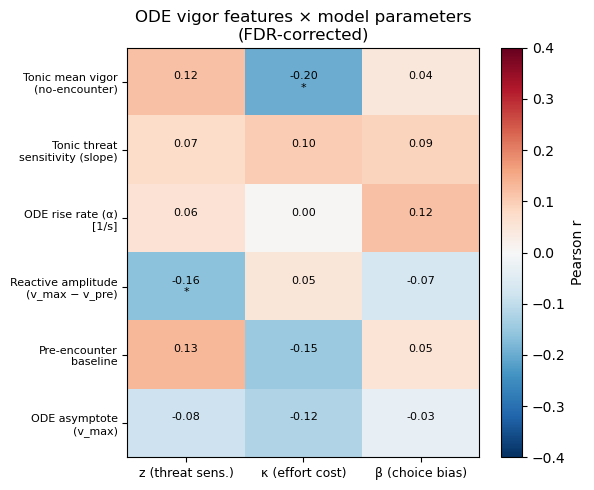

In [10]:
# ── Heatmap: correlation matrix ───────────────────────────────────────────────
r_matrix = corr_df.pivot(index='feature', columns='param', values='r').loc[vigor_features, model_params]
p_matrix = corr_df.pivot(index='feature', columns='param', values='p_fdr').loc[vigor_features, model_params]

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(r_matrix.values, cmap='RdBu_r', vmin=-0.4, vmax=0.4, aspect='auto')
plt.colorbar(im, ax=ax, label='Pearson r')

ax.set_xticks(range(len(model_params)))
ax.set_xticklabels([param_labels[p] for p in model_params], fontsize=9)
ax.set_yticks(range(len(vigor_features)))
ax.set_yticklabels([feature_labels[f] for f in vigor_features], fontsize=8)

for i, feat in enumerate(vigor_features):
    for j, param in enumerate(model_params):
        r_val = r_matrix.loc[feat, param]
        p_val = p_matrix.loc[feat, param]
        sig_str = '***' if p_val < 0.001 else ('**' if p_val < 0.01 else ('*' if p_val < 0.05 else ''))
        ax.text(j, i, f'{r_val:.2f}\n{sig_str}', ha='center', va='center',
                fontsize=8, color='white' if abs(r_val) > 0.25 else 'black')

ax.set_title('ODE vigor features × model parameters\n(FDR-corrected)')
plt.tight_layout()
plt.savefig(FIG_DIR / 'D_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

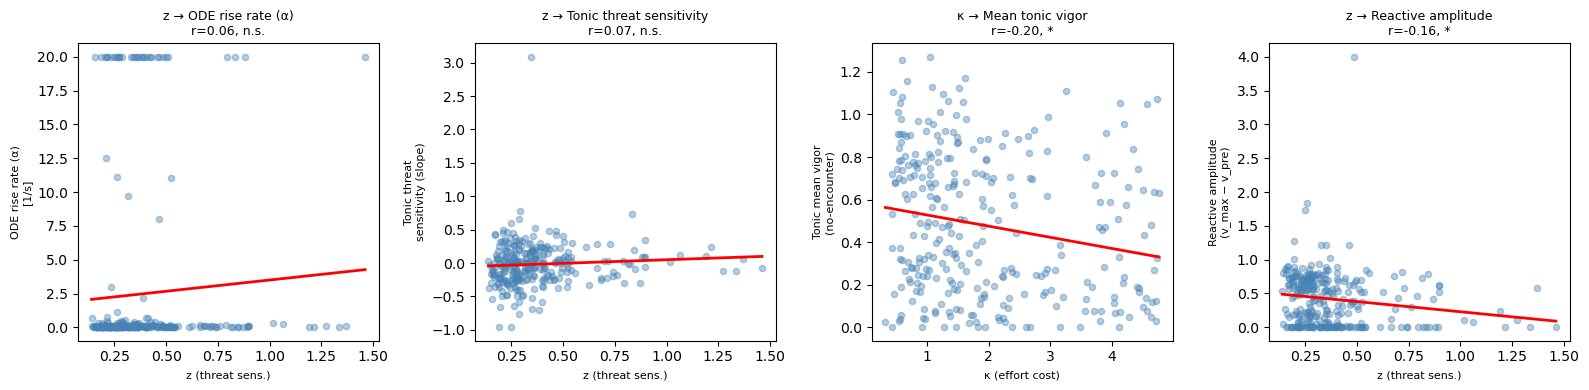

In [11]:
# ── Scatter plots for key predicted associations ──────────────────────────────
key_pairs = [
    ('z',     'alpha',               'z → ODE rise rate (α)'),
    ('z',     'tonic_threat_slope',  'z → Tonic threat sensitivity'),
    ('kappa',  'v_tonic_mean',       'κ → Mean tonic vigor'),
    ('z',     'v_amplitude',         'z → Reactive amplitude'),
]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, (param, feat, title) in zip(axes, key_pairs):
    x = subj_features[param].values
    y = subj_features[feat].values
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    ax.scatter(x, y, alpha=0.4, s=20, color='steelblue')
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax.plot(x_line, m * x_line + b, 'r-', lw=2)

    r, p = pearsonr(x, y)
    p_fdr_val = corr_df[(corr_df['param']==param) & (corr_df['feature']==feat)]['p_fdr'].values[0]
    sig_str = '***' if p_fdr_val < 0.001 else ('**' if p_fdr_val < 0.01 else ('*' if p_fdr_val < 0.05 else 'n.s.'))
    ax.set_title(f'{title}\nr={r:.2f}, {sig_str}', fontsize=9)
    ax.set_xlabel(param_labels.get(param, param), fontsize=8)
    ax.set_ylabel(feature_labels.get(feat, feat), fontsize=8)

plt.tight_layout()
plt.savefig(FIG_DIR / 'E_scatter_key_pairs.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Save results

In [12]:
# Save ODE parameters per subject
out = (
    subj_features[['subj','v_pre','v_max','alpha','v_amplitude',
                    'v_tonic_mean','tonic_threat_slope','n_enc_trials',
                    'z','kappa','beta']]
    .copy()
)
out.to_csv(STATS_DIR / 'vigor_ode_params.csv', index=False)
print(f'Saved: {STATS_DIR / "vigor_ode_params.csv"} ({len(out)} subjects)')

# Save correlation table
corr_df.to_csv(STATS_DIR / 'vigor_ode_correlations.csv', index=False)
print(f'Saved: {STATS_DIR / "vigor_ode_correlations.csv"}')

# Summary
print()
print('=== KEY RESULTS ===')
print()
sig_corrs = corr_df[corr_df['sig']].sort_values('p_fdr')
if len(sig_corrs) == 0:
    print('No significant correlations survived FDR correction.')
    print('→ ODE vigor dynamics are largely independent of FET model parameters.')
    print('→ Vigor reflects urgency but is not well-predicted by the computational model.')
else:
    print(f'Significant correlations (FDR q<0.05): {len(sig_corrs)}')
    for _, row in sig_corrs.iterrows():
        print(f"  {row['feature']} ~ {row['param']}: r={row['r']:+.3f}, p_fdr={row['p_fdr']:.3f}")

Saved: /Users/nokada/Desktop/EffortForagingUnderThreat/results/stats/vigor_ode_params.csv (293 subjects)
Saved: /Users/nokada/Desktop/EffortForagingUnderThreat/results/stats/vigor_ode_correlations.csv

=== KEY RESULTS ===

Significant correlations (FDR q<0.05): 2
  v_tonic_mean ~ kappa: r=-0.199, p_fdr=0.011
  v_amplitude ~ z: r=-0.165, p_fdr=0.042
